# **Alvos categóricos em NN**
<font size=3>

Na aula passada, desenvolvemos um modelo para a **tarefa de regressão**, onde a função de activação *sigmoid* limitava o intervalo da **camada de saída**. Aqui, iremos aprender como lidar com **alvos categóricos** a fim de realizarmos **tarefas de classificação** com uma rede neural.

Modelos de *deep learning* não são adequados para retornar respostas de valores inteiros, como duas classes [0, 1]. Ao invés disso, os modelos retornam a **probabilidade** de cada categoria ser a resposta correta.

Então, vamos compreender:
1. Como **codificar dados categóricos** em distribuição de probabilidade;
2. Como a **NN retorna** uma distribuição de probabilidade;
3. Qual **função de perda** otimiza distribuições de probabilidade.
   

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import datasets, activations, losses

## **1. Transformando dados categóricos:**
<font size=3>

Vamos considerar a **tarefa de classificação** usando o conjunto de dados clássico [MNIST](https://en.wikipedia.org/wiki/MNIST_database) de dígitos manuscritos. Os dados estão disponíveis no [banco de dados do Keras](https://keras.io/api/datasets/mnist/).

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x-train:(60000, 28, 28), y-train:(60000,)
x-test:(10000, 28, 28), y-test:(10000,)


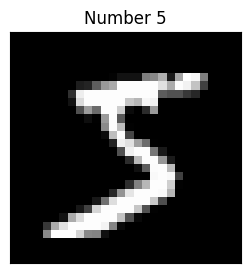

In [2]:
# importando os dados MNIST:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data(path="mnist.npz")

print(f"x-train:{x_train.shape}, y-train:{y_train.shape}")
print(f"x-test:{x_test.shape}, y-test:{y_test.shape}")

# visualizando os dígitos manuscritos:
i = 0

plt.figure(figsize=(5,3))
plt.title("Number "+str(y_train[i]))
plt.imshow(x_train[i], cmap='gray')
plt.xticks([])
plt.yticks([])
plt.show()

### **1.1 Codificação _one-hot_:**
<font size=3>

A **codificação _one-hot_** é uma técnica para codificação numérica de **dados multiclasse**, como os rótulos de dígitos $(0,1,2,3,4,5,6,7,8,9)$. Ela envolve representar um rótulo como um **vetor binário** com o mesmo tamanho que o número de classes. O índice correspondente ao rótulo recebe o valor 1 (hot), enquanto todos os outros índices recebem 0. Este vetor é então interpretado como a **distribuição de probabilidade alvo**, onde a confiança na classe correta é 100%.

$0:(1,0,0,0,0,0,0,0,0,0);\; 1: (0,1,0,0,0,0,0,0,0,0);\; \cdots;\; 9: (0,0,0,0,0,0,0,0,0,1)$

Para o dígito $\mathbf 3$, o modelo pode gerar na saída:
$$
    (0.0533, 0.0123, 0.0085, \mathbf{0.6542}, 0.0005, 0.1659, 0.0208, 0.0038, 0.0799, 0.0009)
$$

Podemos usar a função [*one-hot* do TensorFlow](https://www.tensorflow.org/api_docs/python/tf/one_hot) para fazer a codificação.    

In [5]:
y_hot = tf.one_hot(y_train[:4], depth=10)

print("Antes da codificação: y-train[0:4] =\n", y_train[:4], "\n")

y_hot = tf.one_hot(y_train[:4], depth=10)

print("Após a codificação: y-train[0:4] =\n", y_hot, "\n")

Antes da codificação: y-train[0:4] =
 [5 0 4 1] 

Após a codificação: y-train[0:4] =
 tf.Tensor(
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]], shape=(4, 10), dtype=float32) 



## **2. A função de ativação _softmax_:**
<font size=3>

Quando o modelo precisa que o vetor de saída seja uma distribuição de probabilidade, nós usamos a função de ativação [softmax](https://en.wikipedia.org/wiki/Softmax_function) para um intervalo $[0,\, 1]$ e soma 1, dado por
$$
    \sigma_l(x^i) = \frac{e^{x^i}}{\sum_{j=1} e^{x^j}} \, .
$$

Σ(σ) = 1.00


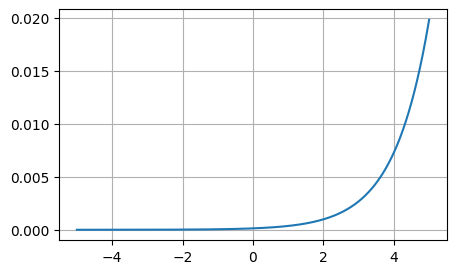

In [6]:
x = np.linspace(-5, 5, 500)

σ = activations.softmax(x)

print(f"Σ(σ) = {np.sum(σ):.2f}")

plt.figure(figsize=(5, 3))
plt.plot(x, σ)
plt.grid()
plt.show()

<font size=3>

**Observe** abaixo que a função exponencial nos permite **distinguir** a normalização de dois vetores de mesmo fator de escala:

In [7]:
# comparand a função softmax com uma normalização padrão:
def norm(x):
    return x/np.sum(x)

v1 = np.array([3.0, 6.0])
v2 = np.array([6.0, 12.0])

print(f"norm([3, 6]) = {norm(v1)}, norm([6, 12]) = {norm(v2)}\n")
print(f"softmax([3, 6]) = {activations.softmax(v1)}, softmax([6, 12]) = {activations.softmax(v2)}")

norm([3, 6]) = [0.33333333 0.66666667], norm([6, 12]) = [0.33333333 0.66666667]

softmax([3, 6]) = [0.04742587 0.95257413], softmax([6, 12]) = [0.00247262 0.99752738]


## **3. A função de perda:**
<font size=3>

Para a otimização da **função de perda**, a função [cross-entropy](https://en.wikipedia.org/wiki/Cross-entropy) pode ser usada para lidar com distribuições de probabilidades. Ela mede a correspondência entre as distribuições predita $q$ e a verdadeira $p$,
$$
    H(p,\, q) = -\sum_i p_i\,\ln q_i \, .
$$

<font size=3>

No Keras, nós temos uma [lista de funções de perda de probabilidades](https://keras.io/api/losses/), onde a [_categorical cross-entropy_](https://keras.io/api/losses/probabilistic_losses/#categoricalcrossentropy-class) é a que melhor se encaixa para tarefas de **multiclasses**. Já para apenas **duas classes**, usamos a [binary cross-entropy](https://keras.io/api/losses/probabilistic_losses/#binarycrossentropy-class) para um processamento mais rápido.

In [8]:
p = np.array([0.0, 1.0, 0.0, 0.0])  # distribuição verdadeira (one-hot)

q1 = np.array([0.8, 5.5, 5.2, 2.3]) # predição 1
q2 = np.array([0.0, 9.5, 3.2, 0.1]) # predição 2

H1 = losses.CategoricalCrossentropy()(p, q1)
print("H1 (grande desordem) =", H1)

H2 = losses.CategoricalCrossentropy()(p, q2)
print("H2 (pequena desordem) =", H2)

H1 (grande desordem) = tf.Tensor(0.9199205, shape=(), dtype=float32)
H2 (pequena desordem) = tf.Tensor(0.29815337, shape=(), dtype=float32)


## **Referências:**
<font size=3>
    
* [Softmax activation function: how it actually works](https://towardsdatascience.com/softmax-activation-function-how-it-actually-works-d292d335bd78);
* [Cross-entropy loss function](https://towardsdatascience.com/cross-entropy-loss-function-f38c4ec8643e).